In [1]:
from typing import TypedDict, Annotated, Sequence
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.prebuilt import ToolNode
from langchain_ollama import ChatOllama
from langchain_core.tools import tool

from dotenv import load_dotenv
from RAG_module import rewrite_question_if_needed, mmr_retriever

load_dotenv()

c:\Users\Vyacheslave\Desktop\AI-assistant\rag_langchain_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 38338.80it/s]
RobertaModel LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                 | Status  | 
--------------------+---------+-
pooler.dense.weight | MISSING | 
pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\Vyacheslave\Desktop\AI-assistant\RAG_module.py:71: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and 

True

### Отключаем логгирование на LangSmith (пока что)

In [2]:
import os
os.environ["LANGCHAIN_TRACING_V2"] = "True"  # Отключает логирование в LangSmith
os.environ["LANGCHAIN_PROJECT"]

import langchain
langchain.debug = True

In [3]:
base_llm = ChatOllama(
    model="llama3.1:latest",
    temperature=0.0
)

llm_with_tools = base_llm  # будет bind позже
llm_plain = base_llm


# =========================
# SYSTEM PROMPT
# =========================
system_prompt = """
Ты AI-агент компании smartclimat74.

Твоя задача:
1. Понимать запрос пользователя
2. При необходимости использовать инструменты
3. Давать рекомендации по товарам и услугам
4. Быть вежливым

СТРОГО:
- Отвечай только по теме климатического оборудования
- Если получил результат инструмента — ОБЯЗАТЕЛЬНО используй его в ответе
- Если вопрос не по теме — откажи

ПРАВИЛА ВЫЗОВА ИНСТРУМЕНТОВ:
- При вызове retriever_tool передавай только текст запроса в аргумент query.
- Не используй лишние символы, скобки [] или ключи типа <nil>.

ПРАВИЛА РАБОТЫ С РЕЗУЛЬТАТАМИ ПОИСКА:
- Если инструмент вернул несколько вариантов товаров, ОБЯЗАТЕЛЬНО кратко перечисли как минимум 3-5 наиболее подходящих моделей.
- Для каждого товара укажи название и 1-2 ключевых отличия (например, цена, площадь охлаждения или наличие Wi-Fi).
- Если товаров много, не пиши полотно текста про один, лучше сделай краткий сравнительный список.
- Если в результатах поиска есть акции или гарантия — упомяни об этом.

Пример отказа:
"Я могу помочь только с вопросами по оборудованию и услугам smartclimat74"
"""


### Инструменты для вызова

In [4]:
@tool
def retriever_tool(query: str) -> str:
    """Search for air conditioning products and services. 
    Input should be a simple search string."""
    
    print("\n=== RAG Tool ===")
    
    rewriten_query = rewrite_question_if_needed(query)
    
    try:
        docs = mmr_retriever.invoke(rewriten_query)
    except Exception as e:
        return f"Ошибка поиска: {str(e)}"

    if not docs:
        return "Информация не найдена"

    results = []
    for i, doc in enumerate(docs):
        content = doc.page_content[:1000]
        results.append(f"Документ {i+1}:\n{content}")

    return "\n\n".join(results)

from langgraph.prebuilt import InjectedState


tools = [retriever_tool]

# теперь биндим tools
llm_with_tools = base_llm.bind_tools(tools)

### Состояние агента (графа)

In [5]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    rewritten_query: str

### Условные ребра


In [6]:
def classify_llm_router(state: AgentState) -> str:
    last_message = state["messages"][-1].content

    prompt = f"""
Классифицируй запрос пользователя для климатической компании smartclimat74.

Варианты:
- products_services: поиск конкретных товаров, цены, подбор оборудования.
- consultation: приветствия, общие вопросы о климате, советы, "как выбрать", благодарности.
- off_topic: вопросы, которые не касаются климатического и вентиляционного оборудования и всё что связанного с этой темой.

Запрос: {last_message}

Ответь строго одним словом из списка выше.
"""

    result = llm_plain.invoke([
        SystemMessage(content="Ты классификатор. Отвечай строго одним словом."),
        HumanMessage(content=prompt)
    ])

    text = result.content.strip().lower()

    if "product" in text:
        return "products_services"
    elif "consult" in text:
        return "consultation"
    elif "off" in text:
        return "off_topic"
    else:
        return "consultation"

### Узлы

In [7]:
# --- основной LLM (с инструментами)
def llm_node(state: AgentState) -> AgentState:
    """
    Если нужно использовать инструменты
    """
    messages = [SystemMessage(content=system_prompt)] + list(state["messages"])
    response = llm_with_tools.invoke(messages)

    return {"messages": [response]}


# --- консультация (без инструментов)
def consultation_node(state: AgentState) -> AgentState:
    consultation_prompt = """
Ты консультант smartclimat74.
Отвечай на вопросы, давай советы и рекомендации.
Не используй инструменты.
"""

    messages = [
        SystemMessage(content=system_prompt),
        SystemMessage(content=consultation_prompt),
    ] + list(state["messages"])

    response = llm_plain.invoke(messages)

    return {"messages": state["messages"] + [response]}


# --- отказ
def reject_node(state: AgentState) -> AgentState:
    reject_prompt = """
Вежливо откажи, и напомни, что ты AI-ассистент компании специлизирующийся на вопросах о продукции и услугах компании.
"""

    messages = [SystemMessage(content=reject_prompt)] + list(state["messages"])

    response = llm_plain.invoke(messages)

    return {"messages": state["messages"] + [response]}

# --- tools node (готовый!)
tool_node = ToolNode(tools)

In [8]:
def should_use_tools(state):
    last = state["messages"][-1]
    return hasattr(last, "tool_calls") and len(last.tool_calls) > 0

### Конфиг графа

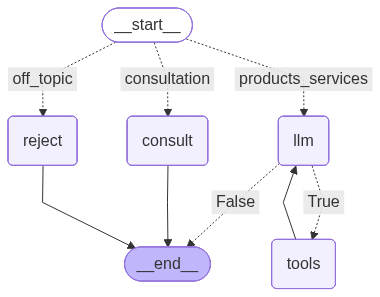

In [9]:
graph = StateGraph(AgentState)

graph.add_node("llm", llm_node)
graph.add_node("consult", consultation_node)
graph.add_node("reject", reject_node)
graph.add_node("tools", tool_node)


# 🔥 правильная архитектура: сначала router
graph.add_conditional_edges(
    START,
    classify_llm_router,
    {
        "products_services": "llm",
        "consultation": "consult",
        "off_topic": "reject"
    }
)

# если LLM вызвал tool → идём в tools
graph.add_conditional_edges(
    "llm",
    should_use_tools,
    {
        True: "tools",
        False: END
    }
)

# после tools → обратно в LLM
graph.add_edge("tools", "llm")

graph.add_edge("consult", END)
graph.add_edge("reject", END)


rag_agent = graph.compile()

from IPython.display import Image, display
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [10]:
def run_agent():
    print("\n=== RAG AGENT ===")

    # 1. Инициируем приветствие. 
    # Мы как бы имитируем, что пользователь зашел на страницу.
    initial_state = {
        "messages": [HumanMessage(content="Привет! Расскажи о себе и как ты можешь помочь.")]
    }
    
    # Запускаем один раз, чтобы получить приветствие
    first_response = rag_agent.invoke(initial_state)
    print(f"\nАгент: {first_response['messages'][-1].content}")

    # 2. Переходим в обычный цикл
    state = first_response # Сохраняем состояние с приветствием

    while True:
        user_input = input("\nВы: ")

        if user_input.lower() in ["exit", "quit"]:
            break

        result = rag_agent.invoke({
            "messages": [HumanMessage(content=user_input)]
        })

        print("\n=== ANSWER ===")
        print(result["messages"][-1].content)

In [11]:
def debug_run_agent():
    print("\n=== RAG AGENT (DEBUG MODE) ===")

    # 1. Инициируем приветствие. 
    # Мы как бы имитируем, что пользователь зашел на страницу.
    initial_state = {
        "messages": [HumanMessage(content="Привет! Расскажи о себе и как ты можешь помочь.")]
    }
    
    # Запускаем один раз, чтобы получить приветствие
    first_response = rag_agent.invoke(initial_state)
    print(f"\nАгент: {first_response['messages'][-1].content}")

    # 2. Переходим в обычный цикл
    state = first_response # Сохраняем состояние с приветствием
    
    while True:
        user_input = input("\nВы: ")
        if user_input.lower() in ["exit", "quit"]:
            break

        # Добавляем новое сообщение к существующему состоянию
        state["messages"].append(HumanMessage(content=user_input))
        
        # Запускаем поток обновлений
        for chunk in rag_agent.stream(state, stream_mode="updates"):
            for node_name, state_update in chunk.items():
                # Обновляем наше состояние данными из графа
                state["messages"].extend(state_update.get("messages", []))
                
                # Если это финальный ответ (не вызов инструмента и не промежуточный узел)
                if node_name in ["llm", "consult", "reject"]:
                    last_msg = state_update["messages"][-1]
                    if not (hasattr(last_msg, "tool_calls") and last_msg.tool_calls):
                        print(f"\nАгент [{node_name}]: {last_msg.content}")

In [12]:
debug_run_agent()


=== RAG AGENT (DEBUG MODE) ===

Агент: Привет! Я - консультант компании smartclimat74, специализирующейся в области климатического оборудования. Моя задача - помочь вам найти или выбрать подходящее решение для ваших потребностей по охлаждению и кондиционированию воздуха.

Я могу предоставить информацию о различных типах климатического оборудования, таких как кондиционеры, вентиляторы, системы охлаждения и другие. Кроме того, я могу помочь с выбором подходящего оборудования для конкретного помещения или ситуации, а также подсказать, как правильно установить и эксплуатировать его.

Если у вас есть какие-либо вопросы или проблемы по теме климатического оборудования, я готов помочь.

Агент [consult]: Я могу помочь только с вопросами по оборудованию и услугам smartclimat74. Если вы хотите узнать больше о нас или нашем продукте, я буду рад помочь!


KeyboardInterrupt: 